Option 1: Pipeline

Create your data pipeline. Complete the following tasks:

Create a data pipeline to process daily tables of raw data to daily processed data tables. Processed daily data should include the basic aggregated information (pseudo_user_id, number of events, device, OS, location, revenue, etc.) of each user of that day. One row for each user in each daily table.

Raw data is from Google Analytics 4 example table bigquery-public-data.ga4_obfuscated_sample_ecommerce (link).The destination should be under your own project and data set, like my_project_name.G4_daily_user.G4_daily_user_20210131

This processing should run automatically daily in Airflow or Mage. [Note that in the real-life scenario, you would always process the data from the previous day, but in this case simply create few daily tables].

All the processing should be done using SQL and data should not be exported from Google Cloud during the processing.

Then demonstrate the visualization of daily aggregated data, like the number of users, and the number of users by country/device/OS in Google Looker studio or any Python library.

The default tool for orchestration is Airflow or Mage, but you can use also other options, like Cloud Composer or MS Fabric. Note that the teacher can fully support only Airflow and Mage. 

Return a short report, where you show the code, screenshots which indicate that the pipeline works and the final visualizations. 
Some additional instructions:

In real life scenario you would typically query daily table of the current day:
WHERE _TABLE_SUFFIX = FORMAT_DATE("%Y%m%d", DATE_SUB(CURRENT_DATE())

Or previous day:
WHERE _TABLE_SUFFIX = FORMAT_DATE("%Y%m%d", DATE_SUB(CURRENT_DATE(), INTERVAL 1 DAY))

And save the results to the table with corresponding suffix.

In this case the data is from 2021. You can just change the source and target dates manually, trigger the pipeline and create bunch of daily tables. 

DataFrame :
   number_of_users  total_events   device   OS       location   total_revenue
0                9           965   mobile  Web         Turkey    319814948068
1               88          7577  desktop  Web          India   3968159434985
2              241         21663   mobile  Web  United States  11027464415081
3                2          1889  desktop  Web         Norway   1528188480631
4              380         39404  desktop  Web  United States  17697397671430


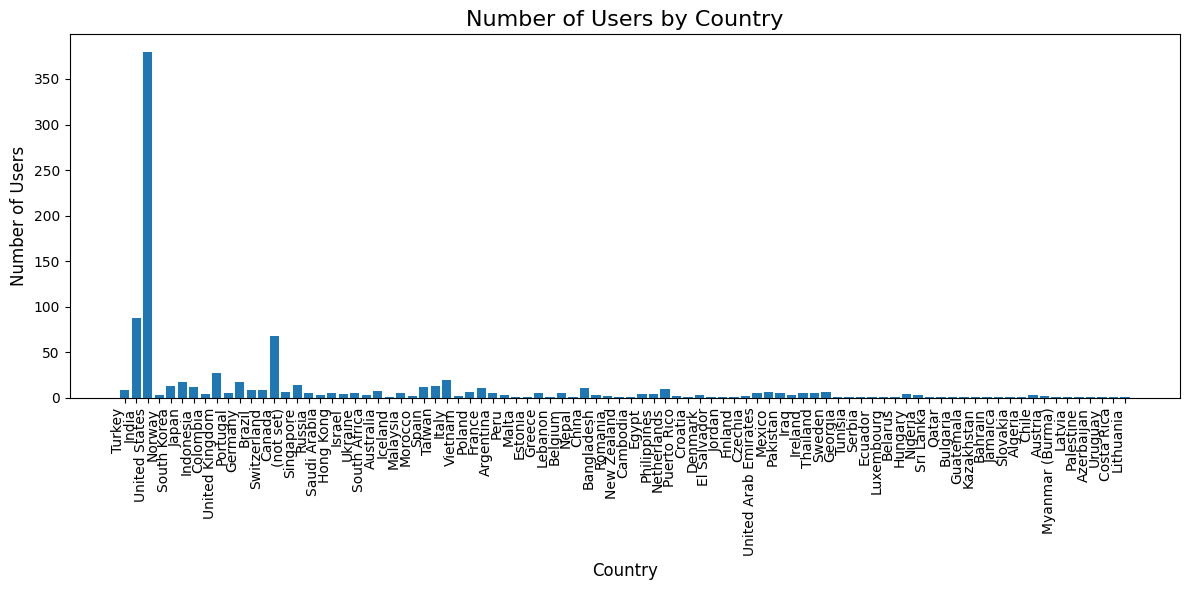

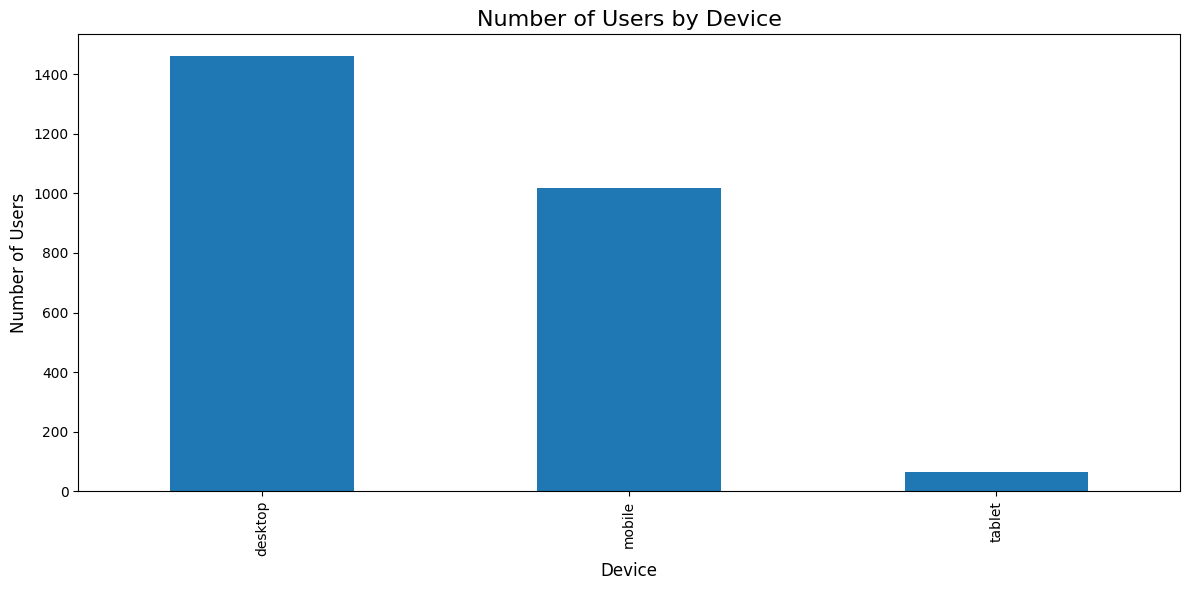

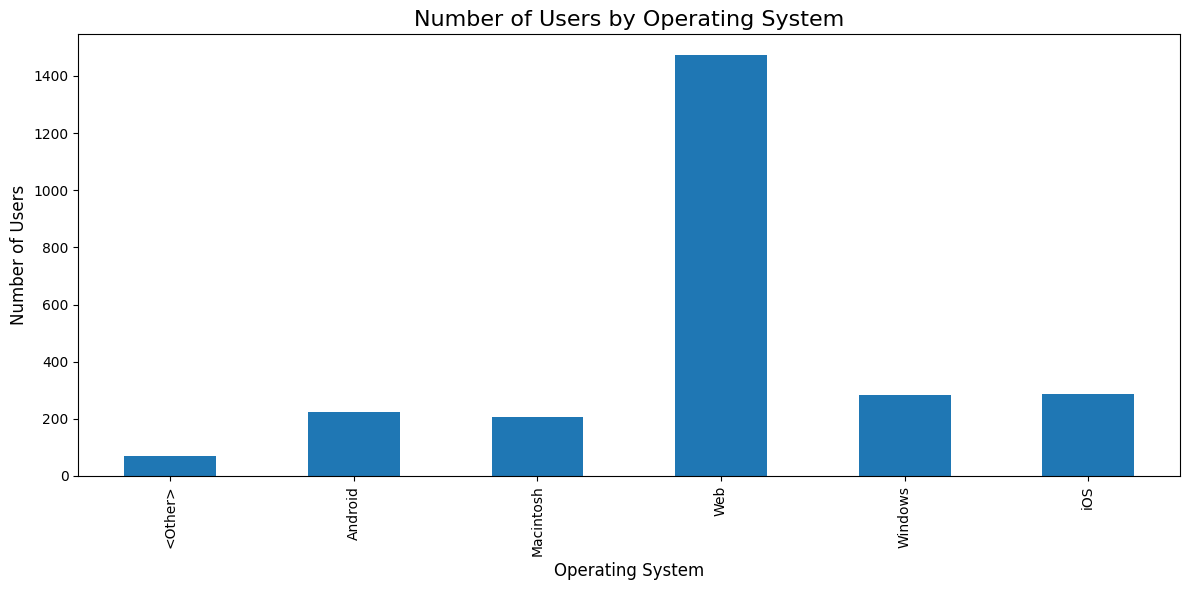

In [2]:
import os
import pandas as pd
from google.cloud import bigquery
import matplotlib.pyplot as plt
#import db_dtypes
from datetime import datetime  # Add datetime import


# load google cloud project details
os.environ["GOOGLE_CLOUD_PROJECT"] = "my-first-project-2024-442313"

client = bigquery.Client()
    # Get current date suffix for table name

current_date_suffix = datetime.now().strftime("%Y%m%d")  # Suffix based on the current date

#query to create table
query = f"""
SELECT
  COUNT(DISTINCT pseudo_user_id) AS number_of_users,
  SUM(num_events) AS total_events,
  device,
  OS,
  location,
  SUM(revenue) AS total_revenue
FROM
  `my-first-project-2024-442313.G4_daily_user.G4_daily_user_{current_date_suffix}`
GROUP BY
  location, device, OS 
"""
# Execute the query 
query_result = client.query(query)

# load query to panda dataframe
df = query_result.to_dataframe()


# Display created dataframe
print("DataFrame :")
print(df.head())



# Visualization: Number of users by location
plt.figure(figsize=(12,6 ))
plt.bar(df['location'], df['number_of_users'])
plt.title('Number of Users by Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# Visualization: Number of users by device
device_data = df.groupby('device')['number_of_users'].sum()
plt.figure(figsize=(12, 6))
device_data.plot(kind='bar')
plt.title('Number of Users by Device', fontsize=16)
plt.xlabel('Device', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.tight_layout()
plt.show()

# Visualization: Number of Users by OS
os_data = df.groupby('OS')['number_of_users'].sum()
plt.figure(figsize=(12, 6))
os_data.plot(kind='bar')
plt.title('Number of Users by Operating System', fontsize=16)
plt.xlabel('Operating System', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.tight_layout()
plt.show()



